In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from optimal_granularity import get_optimal_granularity
from utils import load_shapefile_points, save_results_to_csv
from visualization import make_aligned_grid, plot_grid, plot_heatmap
import pathlib

from optimal_granularity.utils import convert_time_to_scalar

# Burglaries

In [2]:
shapefile_path = "../data/burglaries/burglary.shp"

coords, gdf_coords = load_shapefile_points(shapefile_path)

In [3]:
gdf_coords["datetime"] = pd.to_datetime(
    gdf_coords["burg_date"].astype(str) + " " + gdf_coords["hora"].astype(str) + ":00:00",
    format="%Y-%m-%d %H:%M:%S"
)

min_date = gdf_coords["datetime"].min()

gdf_coords["time_scalar"] = gdf_coords["datetime"].apply(
    lambda x: convert_time_to_scalar(x, min_date)
)

coords_spatiotemporal = np.column_stack([
    coords,
    gdf_coords["time_scalar"].values
])

In [4]:
optimal_granularity = get_optimal_granularity(
    coords_spatiotemporal,
    tradeoff_method="product",
    size_scale=5,
    signif=0.99,
    uniformity_method="quadrat_count",
    uniformity_num_random_quadrats_per_scale=200,
    robustness_num_simulations=200,
    robustness_num_bootstrap=100,
    verbose=True,
)

print(f"Optimal granularity: {optimal_granularity}")

output_csv_path = "results/burglary/results-qc-spatiotemporal.csv"
pathlib.Path(output_csv_path).parent.mkdir(parents=True, exist_ok=True)
save_results_to_csv(optimal_granularity, output_csv_path)

----------------------------------------
Optimal Granularity Calculation
----------------------------------------
Normalizing points to positive coordinates...
Bounding box: BoundingBoxSpatioTemporal(minx=-1e-06, miny=-1e-06, mint=-1e-06, maxx=21963.335534513688, maxy=28982.479408698382, maxt=218242800.000001, volume=1.3892287335009765e+17)
Starting calculating uniformity
Scale: (np.float64(274.5416941939211), np.float64(109121400.00000101)), Uniformity: 0.975, Passed: 195, Total: 200
Scale: (np.float64(274.5416941939211), np.float64(72747600.00000067)), Uniformity: 0.995, Passed: 199, Total: 200
Scale: (np.float64(274.5416941939211), np.float64(54560700.00000051)), Uniformity: 0.99, Passed: 198, Total: 200
Scale: (np.float64(274.5416941939211), np.float64(43648560.0000004)), Uniformity: 1.0, Passed: 200, Total: 200
Scale: (np.float64(274.5416941939211), np.float64(36373800.000000335)), Uniformity: 1.0, Passed: 200, Total: 200
Scale: (np.float64(2951.3232125846516), np.float64(10912140

### Visualization

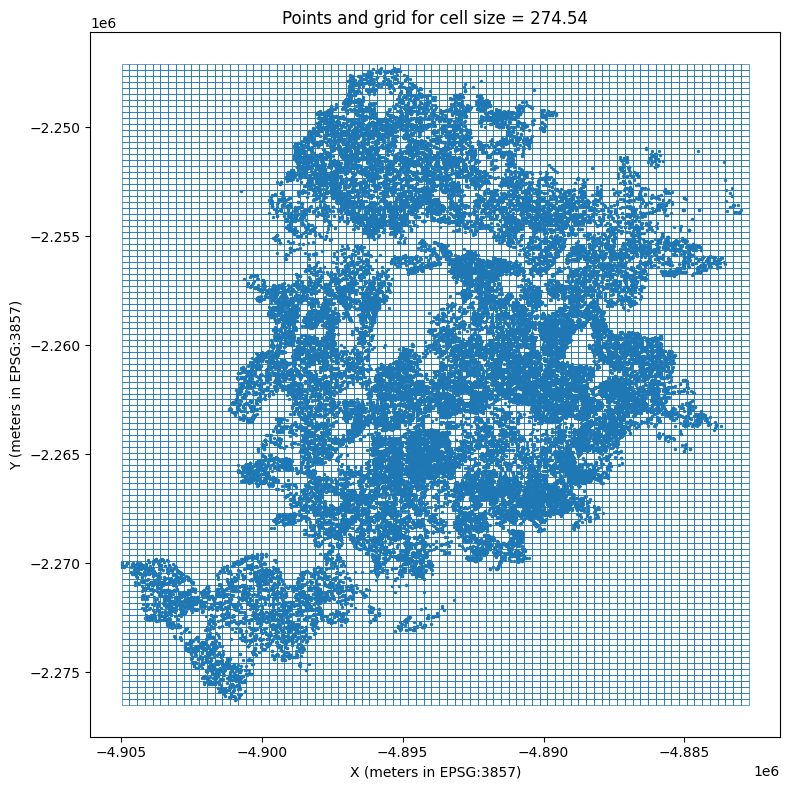

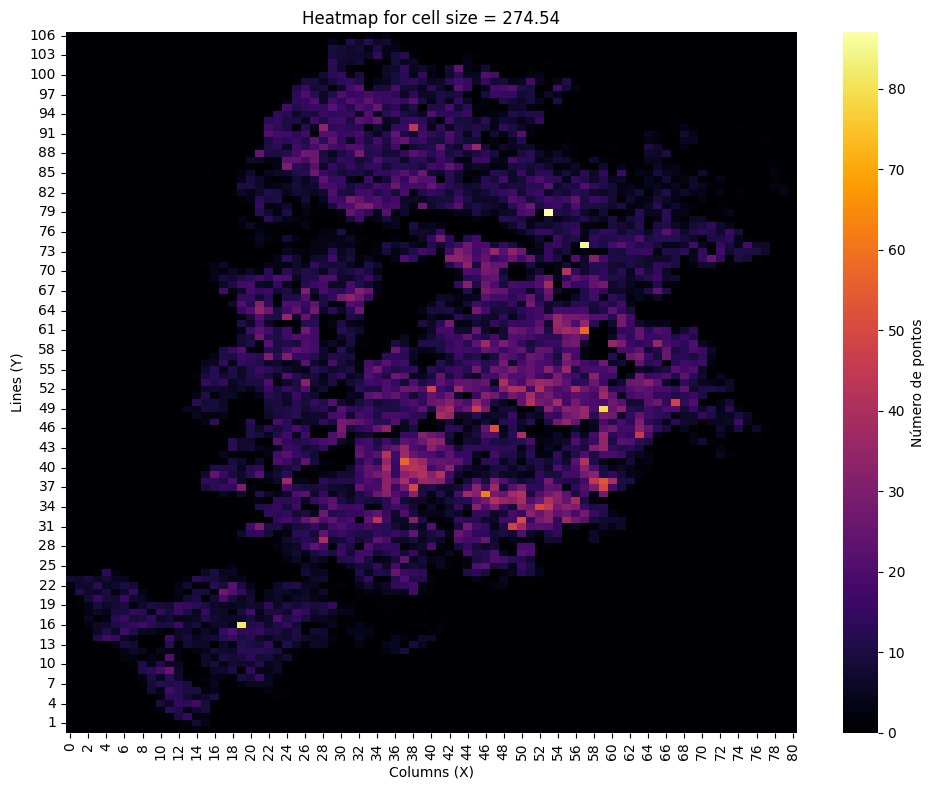

HeatmapStats(mean_all_cells=np.float64(5.141340717664705), mean_nonzero_cells=11.571020514152169)


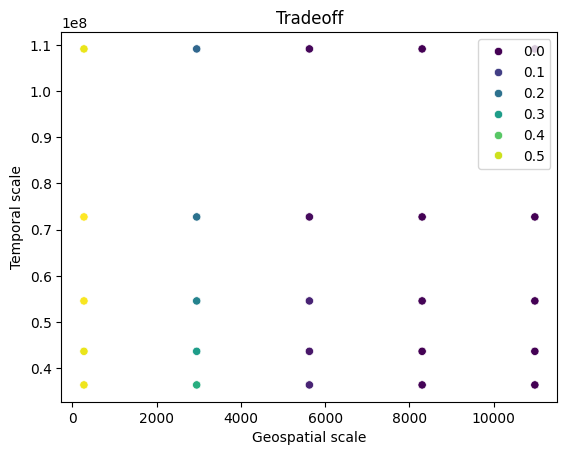

In [5]:
optimal_scale = optimal_granularity.optimal_scale[0]
grid_gdf = make_aligned_grid(gdf_coords, optimal_scale)

plot_grid(gdf_coords, grid_gdf, optimal_scale)
results = plot_heatmap(gdf_coords, grid_gdf, optimal_scale)
print(results)

ax = sns.scatterplot(x=np.array(optimal_granularity.scales)[:, 0], y=np.array(optimal_granularity.scales)[:, 1], hue=optimal_granularity.tradeoff_values, palette="viridis")
ax.set_xlabel("Geospatial scale")
ax.set_ylabel("Temporal scale")
ax.set_title("Tradeoff")
plt.show()

## Geospatial Only

In [6]:
optimal_granularity = get_optimal_granularity(
    coords,
    tradeoff_method="product",
    size_scale=5,
    signif=0.99,
    uniformity_method="quadrat_count",
    uniformity_num_random_quadrats_per_scale=200,
    robustness_num_simulations=200,
    robustness_num_bootstrap=100,
    verbose=True,
)

print(f"Optimal granularity: {optimal_granularity}")

output_csv_path = "results/burglary/results-qc-spatio.csv"
pathlib.Path(output_csv_path).parent.mkdir(parents=True, exist_ok=True)
save_results_to_csv(optimal_granularity, output_csv_path)

----------------------------------------
Optimal Granularity Calculation
----------------------------------------
Normalizing points to positive coordinates...
Bounding box: BoundingBox(minx=-1e-06, miny=-1e-06, maxx=21963.335534513688, maxy=28982.479408698382, area=636551919.9263222, width=21963.33553551369, height=28982.479409698382)
Starting calculating uniformity
Scale: (np.float64(274.5416941939211),), Uniformity: 0.92, Passed: 184, Total: 200
Scale: (np.float64(2951.3232125846516),), Uniformity: 0.175, Passed: 35, Total: 200
Scale: (np.float64(5628.104730975382),), Uniformity: 0.03, Passed: 6, Total: 200
Scale: (np.float64(8304.886249366113),), Uniformity: 0.0, Passed: 0, Total: 200
Scale: (np.float64(10981.667767756844),), Uniformity: 0.0, Passed: 0, Total: 200
Uniformity calculated in 127.68 seconds
Starting calculating robustness
Scale: (np.float64(274.5416941939211),), Robustness: 0.5499
95% CI: (0.5347, 0.5651)
Scale: (np.float64(2951.3232125846516),), Robustness: 0.8825
95%

### Visualization

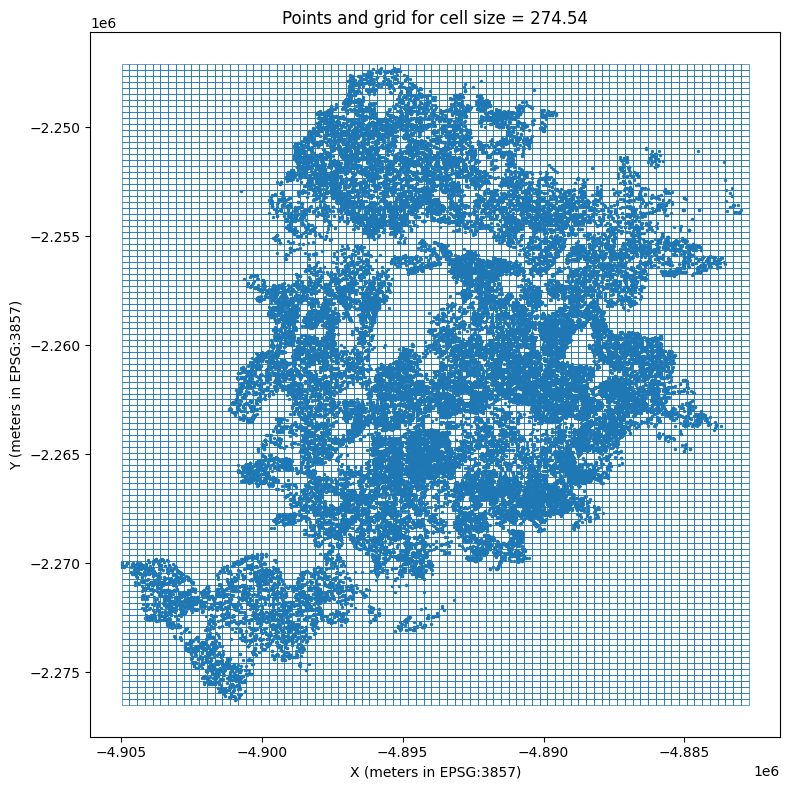

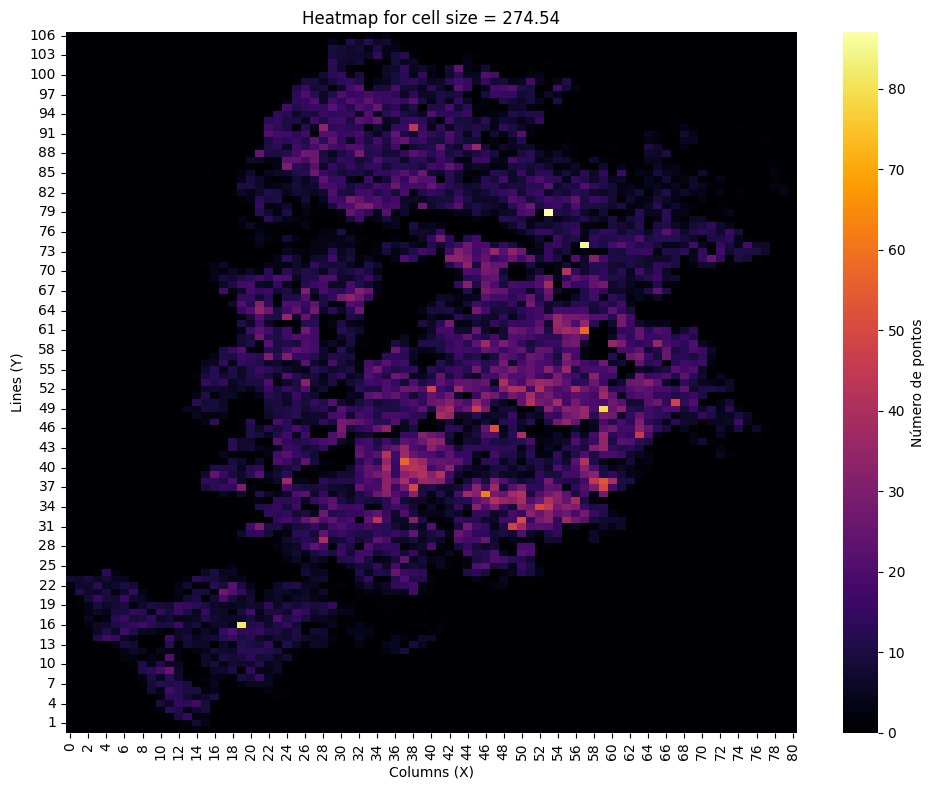

HeatmapStats(mean_all_cells=np.float64(5.141340717664705), mean_nonzero_cells=11.571020514152169)


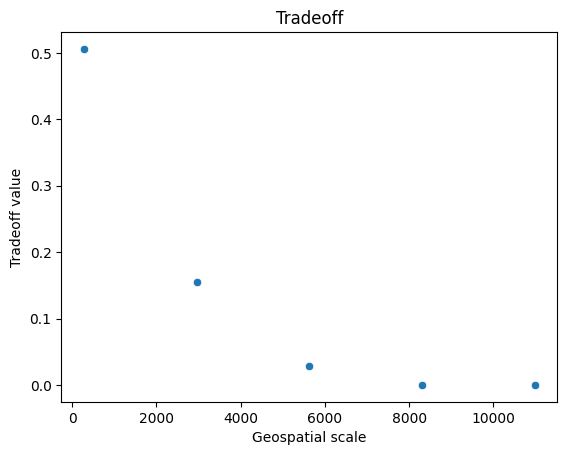

In [10]:
optimal_scale = optimal_granularity.optimal_scale[0]
grid_gdf = make_aligned_grid(gdf_coords, optimal_scale)

plot_grid(gdf_coords, grid_gdf, optimal_scale)
results = plot_heatmap(gdf_coords, grid_gdf, optimal_scale)
print(results)

ax = sns.scatterplot(x=np.array(optimal_granularity.scales)[:, 0], y=optimal_granularity.tradeoff_values)
ax.set_xlabel("Geospatial scale")
ax.set_ylabel("Tradeoff value")
ax.set_title("Tradeoff")
plt.show()

# Chicago

In [11]:
shapefile_path = "../data/chicago/points/chicago_crimes.shp"

coords, gdf_coords = load_shapefile_points(shapefile_path)

In [12]:
gdf_coords["datetime"] = pd.to_datetime(gdf_coords["DATE  OF O"], format="%m/%d/%Y %I:%M:%S %p")

min_date = gdf_coords["datetime"].min()

gdf_coords["time_scalar"] = gdf_coords["datetime"].apply(
    lambda x: convert_time_to_scalar(x, min_date)
)

coords_spatiotemporal = np.column_stack([
    coords,
    gdf_coords["time_scalar"].values
])

In [13]:
optimal_granularity = get_optimal_granularity(
    points=coords_spatiotemporal,
    tradeoff_method="product",
    size_scale=5,
    signif=0.99,
    uniformity_num_random_quadrats_per_scale=200,
    robustness_num_simulations=200,
    robustness_num_bootstrap=100,
    verbose=True,
)

print(f"Optimal granularity: {optimal_granularity}")

output_csv_path = "results/chicago/results-qc-spatiotemporal.csv"
pathlib.Path(output_csv_path).parent.mkdir(parents=True, exist_ok=True)
save_results_to_csv(optimal_granularity, output_csv_path)

----------------------------------------
Optimal Granularity Calculation
----------------------------------------
Normalizing points to positive coordinates...
Bounding box: BoundingBoxSpatioTemporal(minx=-1e-06, miny=5107888.492933717, mint=-1e-06, maxx=45645.06462904973, maxy=5164359.265324849, maxt=31431120.000001, volume=8.10172338299368e+16)
Starting calculating uniformity
Scale: (np.float64(570.5633078756217), np.float64(15715560.000000998)), Uniformity: 0.85, Passed: 170, Total: 200
Scale: (np.float64(570.5633078756217), np.float64(10477040.000000665)), Uniformity: 0.905, Passed: 181, Total: 200
Scale: (np.float64(570.5633078756217), np.float64(7857780.000000499)), Uniformity: 0.915, Passed: 183, Total: 200
Scale: (np.float64(570.5633078756217), np.float64(6286224.0000004)), Uniformity: 0.925, Passed: 185, Total: 200
Scale: (np.float64(570.5633078756217), np.float64(5238520.0000003325)), Uniformity: 0.915, Passed: 183, Total: 200
Scale: (np.float64(6133.555559662933), np.float64

### Visualization

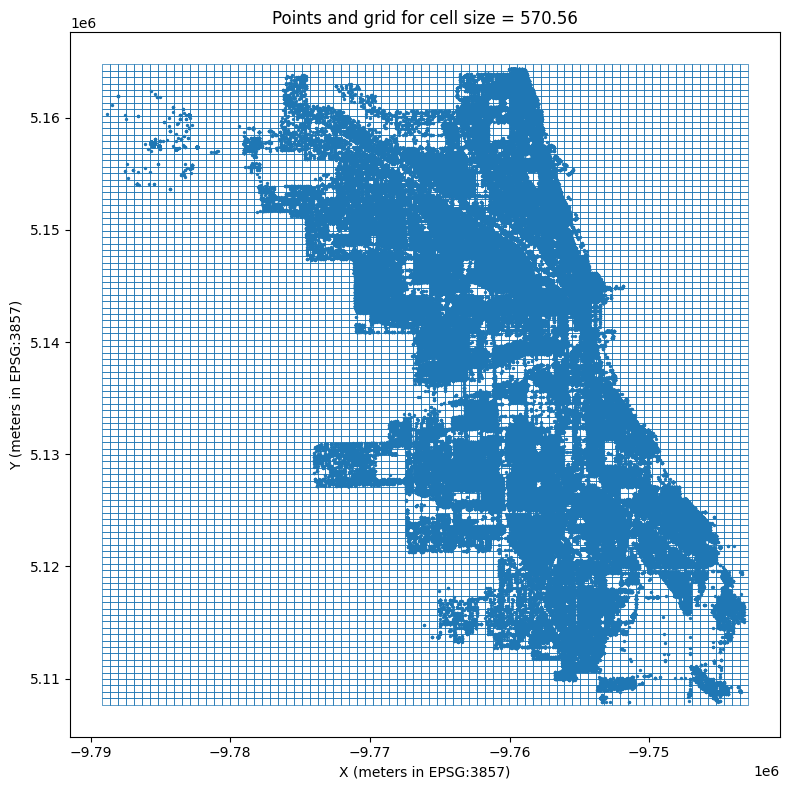

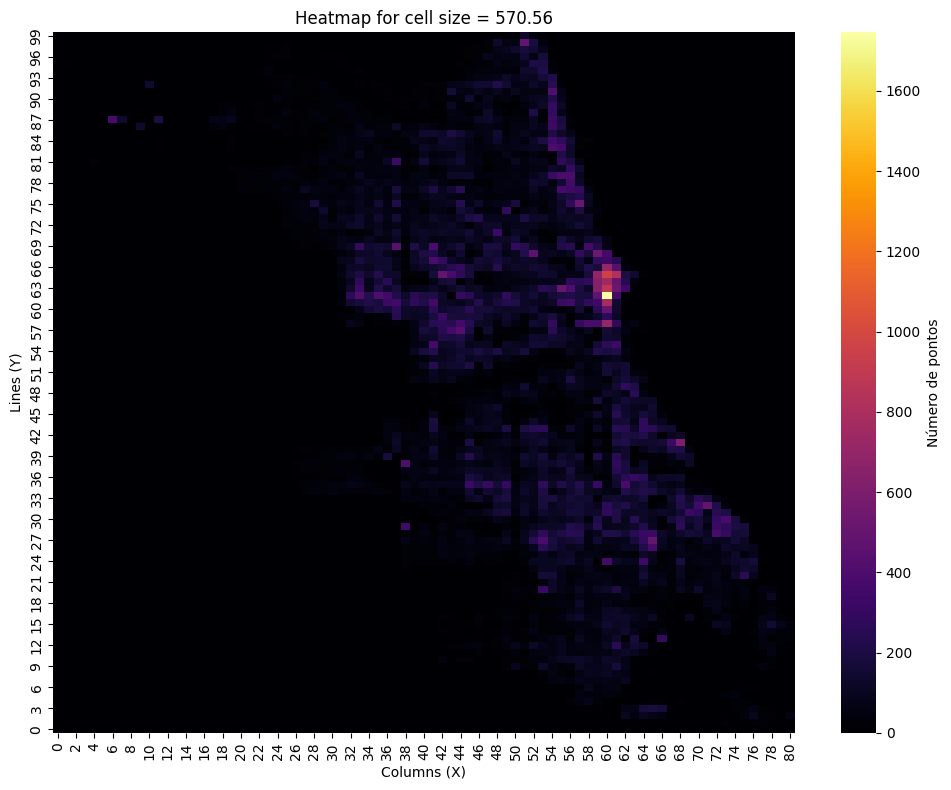

HeatmapStats(mean_all_cells=np.float64(30.786543209876545), mean_nonzero_cells=80.41631731699452)


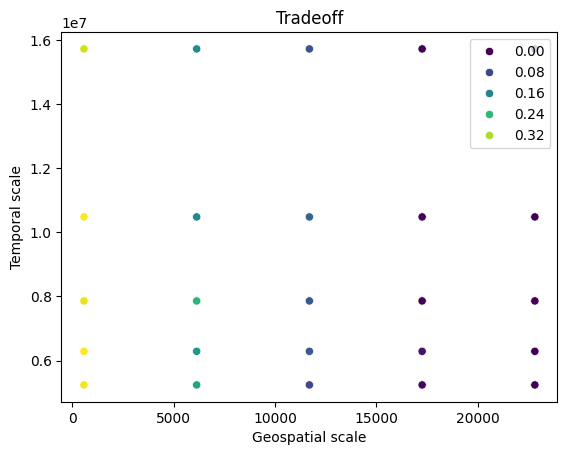

In [14]:
optimal_scale = optimal_granularity.optimal_scale[0]
grid_gdf = make_aligned_grid(gdf_coords, optimal_scale)

plot_grid(gdf_coords, grid_gdf, optimal_scale)
results = plot_heatmap(gdf_coords, grid_gdf, optimal_scale)
print(results)

ax = sns.scatterplot(x=np.array(optimal_granularity.scales)[:, 0], y=np.array(optimal_granularity.scales)[:, 1], hue=optimal_granularity.tradeoff_values, palette="viridis")
ax.set_xlabel("Geospatial scale")
ax.set_ylabel("Temporal scale")
ax.set_title("Tradeoff")
plt.show()

## Geospatial Only

In [15]:
optimal_granularity = get_optimal_granularity(
    points=coords,
    tradeoff_method="product",
    size_scale=5,
    signif=0.99,
    uniformity_num_random_quadrats_per_scale=200,
    robustness_num_simulations=200,
    robustness_num_bootstrap=100,
    verbose=True,
)

print(f"Optimal granularity: {optimal_granularity}")

output_csv_path = "results/chicago/results-qc-spatio.csv"
pathlib.Path(output_csv_path).parent.mkdir(parents=True, exist_ok=True)
save_results_to_csv(optimal_granularity, output_csv_path)

----------------------------------------
Optimal Granularity Calculation
----------------------------------------
Normalizing points to positive coordinates...
Bounding box: BoundingBox(minx=-1e-06, miny=5107888.492933717, maxx=45645.06462904973, maxy=5164359.265324849, area=2577612055.502052, width=45645.06463004973, height=56470.77239113208)
Starting calculating uniformity
Scale: (np.float64(570.5633078756217),), Uniformity: 0.715, Passed: 143, Total: 200
Scale: (np.float64(6133.555559662933),), Uniformity: 0.285, Passed: 57, Total: 200
Scale: (np.float64(11696.547811450244),), Uniformity: 0.09, Passed: 18, Total: 200
Scale: (np.float64(17259.540063237553),), Uniformity: 0.005, Passed: 1, Total: 200
Scale: (np.float64(22822.532315024866),), Uniformity: 0.0, Passed: 0, Total: 200
Uniformity calculated in 582.76 seconds
Starting calculating robustness
Scale: (np.float64(570.5633078756217),), Robustness: 0.4147
95% CI: (0.3988, 0.4306)
Scale: (np.float64(6133.555559662933),), Robustness

### Visualization

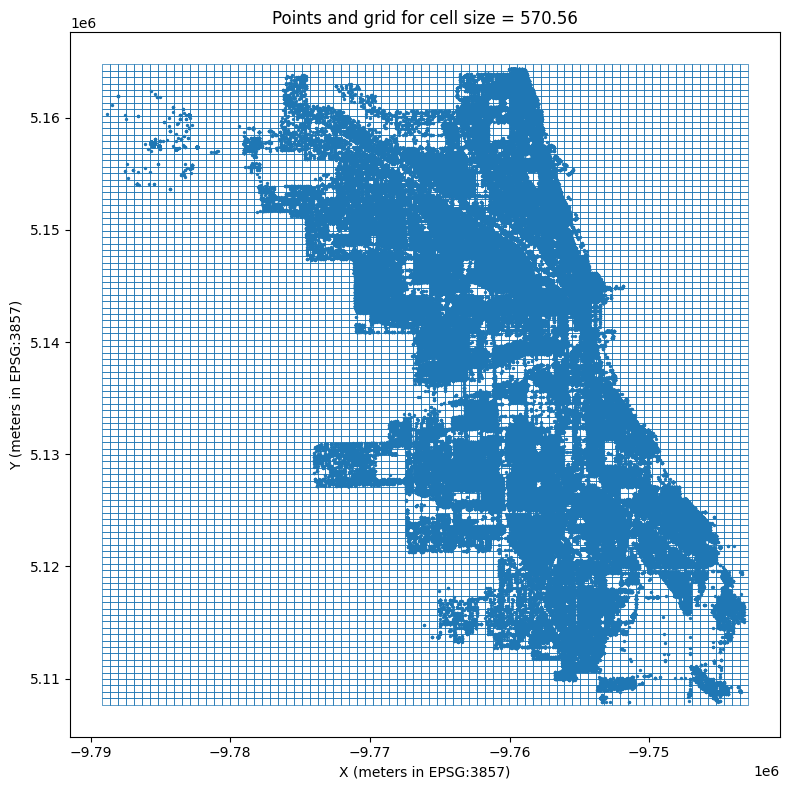

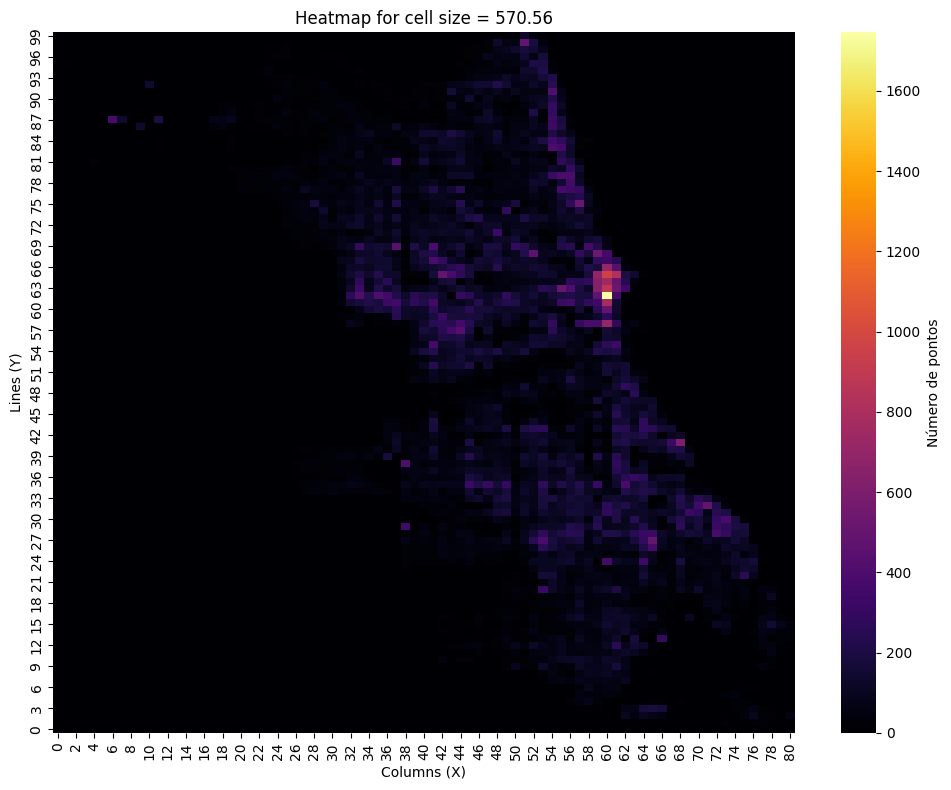

HeatmapStats(mean_all_cells=np.float64(30.786543209876545), mean_nonzero_cells=80.41631731699452)


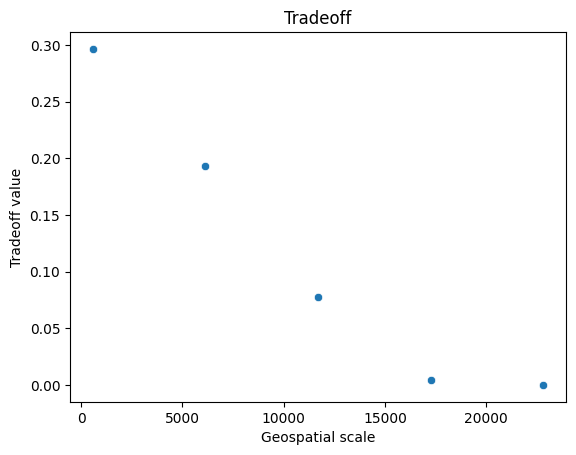

In [16]:
optimal_scale = optimal_granularity.optimal_scale[0]
grid_gdf = make_aligned_grid(gdf_coords, optimal_scale)

plot_grid(gdf_coords, grid_gdf, optimal_scale)
results = plot_heatmap(gdf_coords, grid_gdf, optimal_scale)
print(results)

ax = sns.scatterplot(x=np.array(optimal_granularity.scales)[:, 0], y=optimal_granularity.tradeoff_values)
ax.set_xlabel("Geospatial scale")
ax.set_ylabel("Tradeoff value")
ax.set_title("Tradeoff")
plt.show()

# Fires confirmed 2023 Minneapolis

In [ ]:
shapefile_path = "../data/fires_confirmed_2023_minneapolis/Fires_Confirmed_2023.shp"

coords, gdf_coords = load_shapefile_points(shapefile_path)

In [ ]:
mean_x = np.mean(coords[:, 0])
mean_y = np.mean(coords[:, 1])

dist_from_mean = np.sqrt((coords[:, 0] - mean_x) ** 2 + (coords[:, 1] - mean_y) ** 2)

outlier_indices = np.argsort(dist_from_mean)[-3:]
outlier_coords = coords[outlier_indices]

coords_clean = np.delete(coords, outlier_indices, axis=0)
gdf_coords_clean = gdf_coords.drop(gdf_coords.index[outlier_indices]).reset_index(drop=True)

coords = coords_clean
gdf_coords = gdf_coords_clean

In [ ]:
optimal_granularity = get_optimal_granularity(
    coords,
    tradeoff_method="product",
    size_scale=8,
    signif=0.99,
    uniformity_method="quadrat_count",
    uniformity_num_random_quadrats_per_scale=200,
    robustness_num_simulations=200,
    robustness_num_bootstrap=100,
    # verbose=True,
)

print(f"Optimal granularity: {optimal_granularity}")

output_csv_path = "results/fires-minneapolis/results-qc.csv"
pathlib.Path(output_csv_path).parent.mkdir(parents=True, exist_ok=True)
save_results_to_csv(optimal_granularity, output_csv_path)

### Visualization

In [ ]:
optimal_scale = optimal_granularity.optimal_scale
grid_gdf = make_aligned_grid(gdf_coords, optimal_scale)

plot_grid(gdf_coords, grid_gdf, optimal_scale)
results = plot_heatmap(gdf_coords, grid_gdf, optimal_scale)
print(results)

# Public Incidents Minneapolis

In [ ]:
shapefile_path = "../data/public_incidents_minneapolis/Public_311_Incidents_2020.shp"

coords, gdf_coords = load_shapefile_points(shapefile_path)

In [ ]:
mean_x = np.mean(coords[:, 0])
mean_y = np.mean(coords[:, 1])

dist_from_mean = np.sqrt((coords[:, 0] - mean_x) ** 2 + (coords[:, 1] - mean_y) ** 2)

outlier_indices = np.argsort(dist_from_mean)[-19034:]
outlier_coords = coords[outlier_indices]

coords_clean = np.delete(coords, outlier_indices, axis=0)
gdf_coords_clean = gdf_coords.drop(gdf_coords.index[outlier_indices]).reset_index(drop=True)

coords = coords_clean
gdf_coords = gdf_coords_clean

In [ ]:
optimal_granularity = get_optimal_granularity(
    coords,
    tradeoff_method="product",
    size_scale=8,
    signif=0.99,
    uniformity_method="quadrat_count",
    uniformity_num_random_quadrats_per_scale=200,
    robustness_num_simulations=200,
    robustness_num_bootstrap=100,
    # verbose=True,
)

print(f"Optimal granularity: {optimal_granularity}")

output_csv_path = "results/public-incidents-minneapolis/results-qc.csv"
pathlib.Path(output_csv_path).parent.mkdir(parents=True, exist_ok=True)
save_results_to_csv(optimal_granularity, output_csv_path)

### Visualization

In [ ]:
optimal_scale = optimal_granularity.optimal_scale
grid_gdf = make_aligned_grid(gdf_coords, optimal_scale)

plot_grid(gdf_coords, grid_gdf, optimal_scale)
results = plot_heatmap(gdf_coords, grid_gdf, optimal_scale)
print(results)